# Шаг 1. Обзор данных MovieLens ml-latest-small

## Цель ноутбука
Познакомиться с датасетом MovieLens ml-latest-small: загрузить файлы, изучить структуру, типы данных, пропуски, дубликаты и базовые распределения.

**Что делаем в этом ноутбуке:**
- Загрузка всех 4 CSV-файлов
- Изучение структуры и типов данных
- Анализ пропусков и дубликатов
- Описательная статистика
- Базовые распределения (гистограммы)
- Временной охват датасета
- Анализ жанров
- Формулировка выводов для следующих шагов

**Что НЕ делаем:**
- Никакой очистки, фильтрации, импутации или кодирования
- Никакого обучения моделей
- Никаких записей в `data/processed/` или `models/`

In [1]:
import sys
import os
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.utils import SEED, set_seeds
set_seeds()

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

RAW_DIR = Path('../data/raw')
print(f"SEED = {SEED}")
print(f"RAW_DIR = {RAW_DIR.resolve()}")

SEED = 29042005
RAW_DIR = D:\Git-Project\project\data\raw


## 1. Загрузка датасетов

In [2]:
ratings = pd.read_csv(RAW_DIR / 'ratings.csv')
movies  = pd.read_csv(RAW_DIR / 'movies.csv')
tags    = pd.read_csv(RAW_DIR / 'tags.csv')
links   = pd.read_csv(RAW_DIR / 'links.csv')

print(f"{'Файл':<12} {'Строки':>10} {'Колонки':>10}")
print("-" * 34)
for name, df in [('ratings', ratings), ('movies', movies), ('tags', tags), ('links', links)]:
    print(f"{name:<12} {df.shape[0]:>10,} {df.shape[1]:>10}")

Файл             Строки    Колонки
----------------------------------
ratings         100,836          4
movies            9,742          3
tags              3,683          4
links             9,742          3


## 2. Структура и типы данных

In [3]:
for name, df in [('ratings', ratings), ('movies', movies), ('tags', tags), ('links', links)]:
    print(f"\n{'='*50}")
    print(f"  {name.upper()}.CSV — первые строки")
    print('='*50)
    display(df.head(3))
    print(f"\nТипы данных:")
    display(df.dtypes.to_frame('dtype'))
    print()
    df.info(memory_usage='deep')


  RATINGS.CSV — первые строки


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224



Типы данных:


,dtype
userId,int64
movieId,int64
rating,float64
timestamp,int64



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB

  MOVIES.CSV — первые строки


...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-null   int64 
 2   tag        3683 non-null   object
 3   timestamp  3683 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 327.9 KB

  LINKS.CSV — первые строки


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0



Типы данных:


,dtype
movieId,int64
imdbId,int64
tmdbId,float64



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9742 non-null   int64  
 1   imdbId   9742 non-null   int64  
 2   tmdbId   9734 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 228.5 KB


**Наблюдения по типам данных:**
- `ratings`: колонки `userId`, `movieId` — `int64`, `rating` — `float64`, `timestamp` — `int64` (Unix-время).
- `movies`: `movieId` — `int64`, `title` и `genres` — `object` (строки). Год выпуска закодирован в названии.
- `tags`: аналогично ratings, плюс `tag` — `object`.
- `links`: `movieId` — `int64`, `imdbId` — `int64`, `tmdbId` — `float64` (есть пропуски, поэтому не int).

## 3. Пропуски и дубликаты

In [4]:
# --- Пропуски ---
print("ПРОПУСКИ ПО КОЛОНКАМ")
print("="*60)

for name, df in [('ratings', ratings), ('movies', movies), ('tags', tags), ('links', links)]:
    nulls = df.isnull().sum()
    pct   = (nulls / len(df) * 100).round(2)
    result = pd.DataFrame({'пропуски': nulls, '% от строк': pct})
    result = result[result['пропуски'] > 0]
    if result.empty:
        print(f"\n{name}: пропусков нет ✅")
    else:
        print(f"\n{name}:")
        display(result)

# --- Дубликаты (полные строки) ---
print("\n" + "="*60)
print("ПОЛНЫЕ ДУБЛИКАТЫ СТРОК")
print("="*60)
for name, df in [('ratings', ratings), ('movies', movies), ('tags', tags), ('links', links)]:
    n = df.duplicated().sum()
    print(f"  {name:<10}: {n:>6} дублирующихся строк")

# --- Дубликаты по бизнес-ключам ---
print("\n" + "="*60)
print("ДУБЛИКАТЫ ПО БИЗНЕС-КЛЮЧАМ")
print("="*60)
biz_keys = {
    'ratings': ['userId', 'movieId'],
    'tags':    ['userId', 'movieId', 'tag'],
    'movies':  ['movieId'],
    'links':   ['movieId'],
}
for name, df in [('ratings', ratings), ('movies', movies), ('tags', tags), ('links', links)]:
    keys = biz_keys[name]
    n = df.duplicated(subset=keys).sum()
    print(f"  {name:<10} по {keys}: {n:>6} дублей")

ПРОПУСКИ ПО КОЛОНКАМ

ratings: пропусков нет ✅

movies: пропусков нет ✅

tags: пропусков нет ✅

links:


,пропуски,% от строк
tmdbId,8,0.08



ПОЛНЫЕ ДУБЛИКАТЫ СТРОК
  ratings   :      0 дублирующихся строк
  movies    :      0 дублирующихся строк
  tags      :      0 дублирующихся строк
  links     :      0 дублирующихся строк

ДУБЛИКАТЫ ПО БИЗНЕС-КЛЮЧАМ
  ratings    по ['userId', 'movieId']:      0 дублей
  movies     по ['movieId']:      0 дублей
  tags       по ['userId', 'movieId', 'tag']:      0 дублей
  links      по ['movieId']:      0 дублей


## 4. Описательная статистика

In [5]:
# --- ratings ---
print("Описательная статистика: ratings")
display(ratings.describe())

# --- movies: жанры ---
print("\n" + "="*50)
print("Жанры фильмов (movies.csv)")
all_genres = movies['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts()
print(f"\nВсего уникальных жанровых меток: {all_genres.nunique()}")
print("\nТоп-10 жанров:")
display(genre_counts.head(10).to_frame('кол-во фильмов'))

# --- tags ---
print("\n" + "="*50)
print("Теги (tags.csv)")
print(f"Всего тегов (строк): {len(tags):,}")
print(f"Уникальных тегов: {tags['tag'].nunique():,}")
print("\nТоп-20 тегов:")
display(tags['tag'].value_counts().head(20).to_frame('кол-во применений'))

# --- links ---
print("\n" + "="*50)
print("Ссылки (links.csv)")
tmdb_filled = links['tmdbId'].notna().sum()
print(f"tmdbId заполнен: {tmdb_filled:,} из {len(links):,} ({tmdb_filled/len(links)*100:.1f}%)")

Описательная статистика: ratings


,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09



Жанры фильмов (movies.csv)

Всего уникальных жанровых меток: 20

Топ-10 жанров:


,кол-во фильмов
genres,
Drama,4361
Comedy,3756
Thriller,1894
Action,1828
Romance,1596
Adventure,1263
Crime,1199
Sci-Fi,980
Horror,978



Теги (tags.csv)
Всего тегов (строк): 3,683
Уникальных тегов: 1,589

Топ-20 тегов:


,кол-во применений
tag,
In Netflix queue,131
atmospheric,36
thought-provoking,24
superhero,24
surreal,23
funny,23
Disney,23
religion,22
quirky,21



Ссылки (links.csv)
tmdbId заполнен: 9,734 из 9,742 (99.9%)


## 5. Базовые распределения

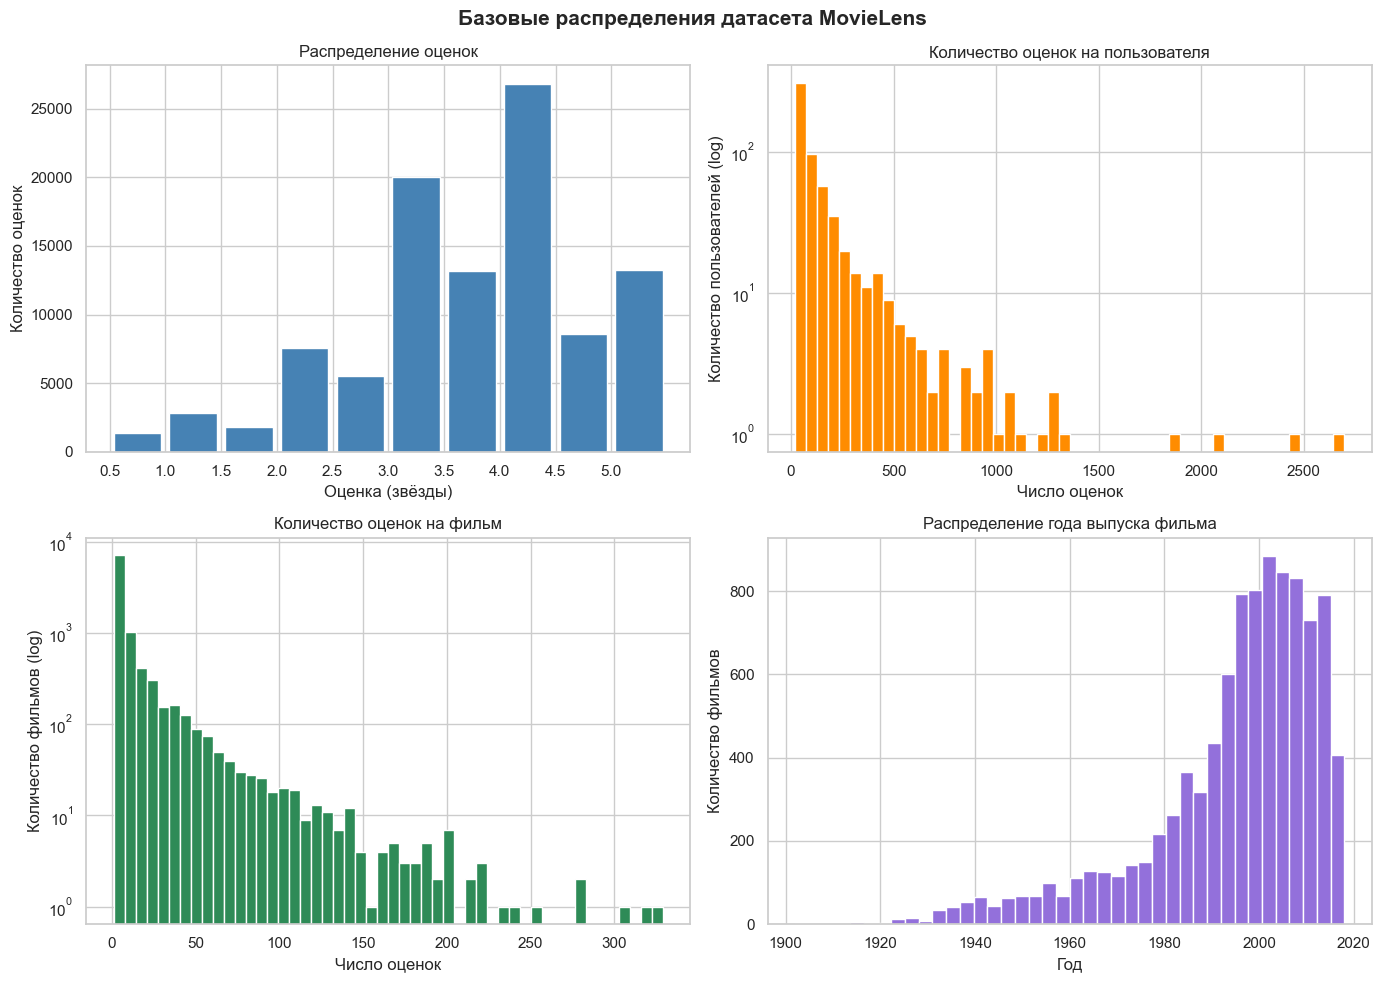

График сохранён.


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Базовые распределения датасета MovieLens', fontsize=15, fontweight='bold')

# (a) Распределение оценок
ax = axes[0, 0]
bins = [x/2 for x in range(1, 12)]  # 0.5, 1.0, ..., 5.0
ratings['rating'].hist(bins=bins, ax=ax, color='steelblue', edgecolor='white', rwidth=0.85)
ax.set_title('Распределение оценок')
ax.set_xlabel('Оценка (звёзды)')
ax.set_ylabel('Количество оценок')
ax.set_xticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

# (b) Оценок на пользователя (log Y)
ax = axes[0, 1]
ratings_per_user = ratings.groupby('userId').size()
ratings_per_user.hist(bins=50, ax=ax, color='darkorange', edgecolor='white')
ax.set_yscale('log')
ax.set_title('Количество оценок на пользователя')
ax.set_xlabel('Число оценок')
ax.set_ylabel('Количество пользователей (log)')

# (c) Оценок на фильм (log Y)
ax = axes[1, 0]
ratings_per_movie = ratings.groupby('movieId').size()
ratings_per_movie.hist(bins=50, ax=ax, color='seagreen', edgecolor='white')
ax.set_yscale('log')
ax.set_title('Количество оценок на фильм')
ax.set_xlabel('Число оценок')
ax.set_ylabel('Количество фильмов (log)')

# (d) Год выпуска
ax = axes[1, 1]
years = movies['title'].str.extract(r'\((\d{4})\)$')[0].dropna().astype(int)
years.hist(bins=40, ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Распределение года выпуска фильма')
ax.set_xlabel('Год')
ax.set_ylabel('Количество фильмов')

plt.tight_layout()
plt.savefig('distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print("График сохранён.")

In [7]:
print("СТАТИСТИКА АКТИВНОСТИ ПОЛЬЗОВАТЕЛЕЙ (оценок на пользователя):")
stats_u = ratings_per_user.describe()
print(f"  Минимум:  {ratings_per_user.min()}")
print(f"  Медиана:  {ratings_per_user.median():.0f}")
print(f"  Среднее:  {ratings_per_user.mean():.1f}")
print(f"  Максимум: {ratings_per_user.max()}")

print("\nСТАТИСТИКА АКТИВНОСТИ ФИЛЬМОВ (оценок на фильм):")
print(f"  Минимум:  {ratings_per_movie.min()}")
print(f"  Медиана:  {ratings_per_movie.median():.0f}")
print(f"  Среднее:  {ratings_per_movie.mean():.1f}")
print(f"  Максимум: {ratings_per_movie.max()}")

one_rating = (ratings_per_movie == 1).sum()
popular = (ratings_per_movie >= 50).sum()
print(f"\nФильмов с ровно 1 оценкой (long tail): {one_rating:,} ({one_rating/len(ratings_per_movie)*100:.1f}%)")
print(f"Фильмов с ≥ 50 оценками:               {popular:,} ({popular/len(ratings_per_movie)*100:.1f}%)")

СТАТИСТИКА АКТИВНОСТИ ПОЛЬЗОВАТЕЛЕЙ (оценок на пользователя):
  Минимум:  20
  Медиана:  70
  Среднее:  165.3
  Максимум: 2698

СТАТИСТИКА АКТИВНОСТИ ФИЛЬМОВ (оценок на фильм):
  Минимум:  1
  Медиана:  3
  Среднее:  10.4
  Максимум: 329

Фильмов с ровно 1 оценкой (long tail): 3,446 (35.4%)
Фильмов с ≥ 50 оценками:               450 (4.6%)


## 6. Временной охват

Временной охват ratings:
  Мин: 1996-03-29 18:36:55
  Макс: 2018-09-24 14:27:30

Временной охват tags:
  Мин: 2006-01-13 19:09:12
  Макс: 2018-09-16 11:50:03


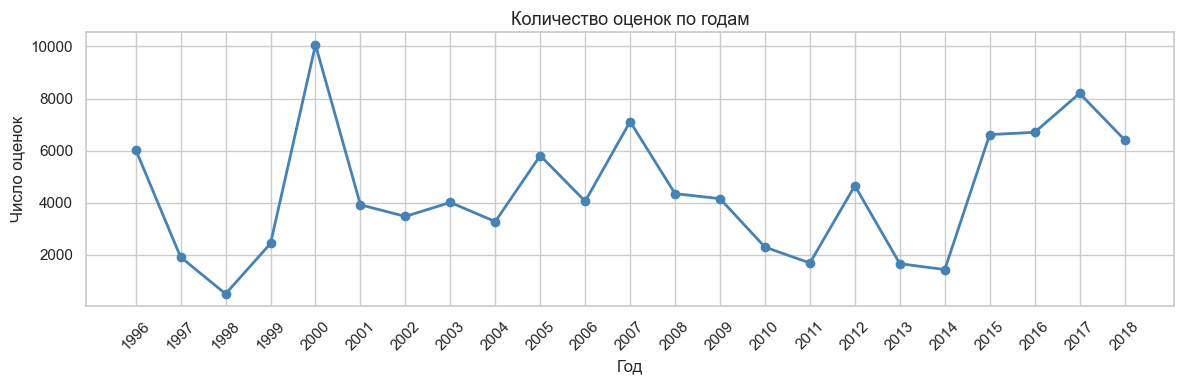

In [8]:
# Конвертация timestamp → datetime
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
tags['datetime']    = pd.to_datetime(tags['timestamp'], unit='s')

print("Временной охват ratings:")
print(f"  Мин: {ratings['datetime'].min()}")
print(f"  Макс: {ratings['datetime'].max()}")

print("\nВременной охват tags:")
print(f"  Мин: {tags['datetime'].min()}")
print(f"  Макс: {tags['datetime'].max()}")

# График: число оценок по годам
fig, ax = plt.subplots(figsize=(12, 4))
ratings_by_year = ratings.groupby(ratings['datetime'].dt.year).size()
ratings_by_year.plot(kind='line', marker='o', ax=ax, color='steelblue', linewidth=2)
ax.set_title('Количество оценок по годам', fontsize=13)
ax.set_xlabel('Год')
ax.set_ylabel('Число оценок')
ax.set_xticks(ratings_by_year.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 7. Жанры

Фильмов без указания жанра '(no genres listed)': 34


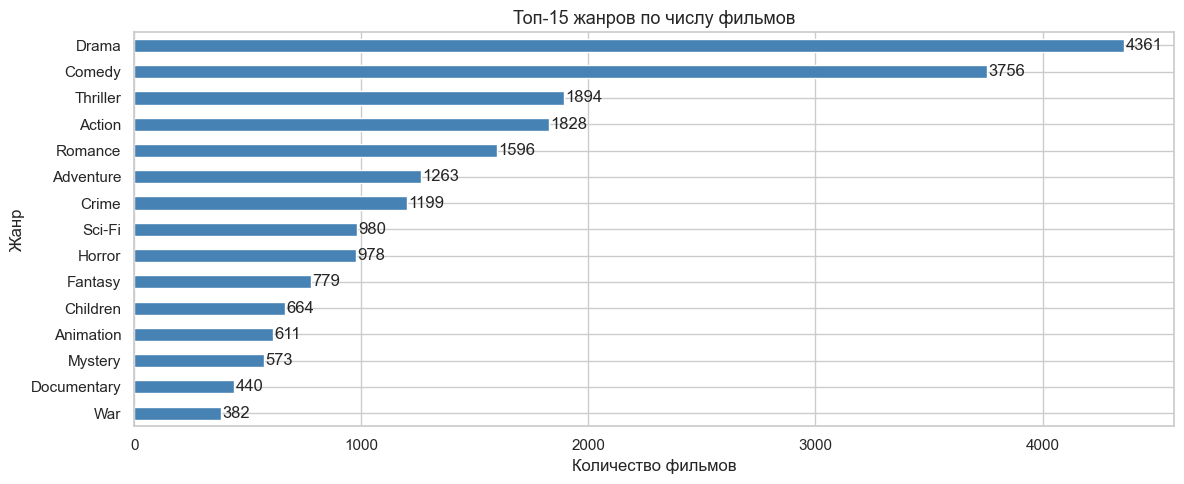

In [9]:
# Распарсить жанры
genres_exploded = movies['genres'].str.split('|').explode()
genre_top15 = genres_exploded.value_counts().head(15)

no_genre = (movies['genres'] == '(no genres listed)').sum()
print(f"Фильмов без указания жанра '(no genres listed)': {no_genre}")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
genre_top15.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Топ-15 жанров по числу фильмов', fontsize=13)
ax.set_xlabel('Количество фильмов')
ax.set_ylabel('Жанр')
for i, v in enumerate(genre_top15.sort_values()):
    ax.text(v + 5, i, str(v), va='center')
plt.tight_layout()
plt.show()

## 8. Выводы

По результатам обзора данных сделаны следующие наблюдения:

1. **Размер датасета адекватен для прототипа.** ~100 836 оценок от 610 пользователей на 9 742 фильма — достаточно для обучения и оценки рекомендательных моделей.

2. **Высокая разреженность матрицы пользователь–фильм (sparsity).** Каждый пользователь оценил в среднем ~165 фильмов из 9 742 (≈1.7%), что означает разреженность ~98.3%. Это типично для рекомендательных задач и требует специальных методов (SVD, ALS, нейросети).

3. **Выраженный «длинный хвост» по фильмам.** Значительная доля фильмов имеет лишь 1–2 оценки. Фильмы с малым числом оценок сложно рекомендовать — на шаге предобработки потребуется фильтрация (порог min_ratings).

4. **Большой разброс активности пользователей.** Число оценок на пользователя варьируется от 20 (минимум по условию датасета) до нескольких тысяч. Активные пользователи могут доминировать в матрице — стоит нормировать или учитывать это при обучении.

5. **Временной диапазон — 22 года (1996–2018).** Вкусы и популярность фильмов меняются со временем. Для более реалистичной оценки качества модели рекомендуется использовать временное разделение выборки (train/test split по времени), а не случайное.

6. **Жанры — мультилейбл, охватывают 20 категорий.** Большинство фильмов относятся к нескольким жанрам одновременно. Drama, Comedy и Thriller — самые частые. Жанры можно использовать как признаки в контентной и гибридной фильтрации (one-hot или multi-hot кодирование).

7. **Есть фильмы без жанра `(no genres listed)`.** Таких фильмов несколько десятков. На шаге предобработки нужно решить, как их обрабатывать: исключать или заменять специальным токеном.

8. **Пропуски только в `links.tmdbId`.** Остальные файлы не содержат пропусков. `tmdbId` может понадобиться для получения постеров или дополнительных метаданных — пропуски нужно учесть при интеграции внешних API.

9. **Теги — свободный текст, нестандартные значения.** Среди тегов встречаются фразы, опечатки, разный регистр. На шаге EDA стоит изучить распределение тегов подробнее для возможного использования в NLP-признаках.

**Следующий шаг:** углублённый EDA (02_eda.ipynb) — анализ корреляций, пользовательских профилей, биас оценок, временных трендов и подготовка данных к моделированию.

In [10]:
# Проверки целостности данных
assert ratings.shape[0] > 100_000, "Ожидается > 100 000 оценок"
assert movies['movieId'].nunique() == movies.shape[0], "movieId должны быть уникальными в movies"
assert ratings['rating'].between(0.5, 5.0).all(), "Оценки должны быть в диапазоне 0.5–5.0"
assert ratings['userId'].nunique() == 610, "Ожидается 610 уникальных пользователей"

print('✅ Шаг 1 пройден: данные загружены и обзор выполнен')

✅ Шаг 1 пройден: данные загружены и обзор выполнен
